# Module 03: Optimization and Statistical Foundations for Machine Learning

---

## 🔗 Building on Previous Modules

**Where this comes from:** Course 02 (AIAT 112) — Unit 4, lesson 01 "04. Optimization Techniques" ran gradient descent on slope intuition alone; that notebook states outright that no calculus was required. Module 02 has now supplied the calculus, so Module 03 returns to the same algorithm and asks the next question: which optimizer, and how do you know it worked?

**Great progress!** You now have the foundation. Let's put it together:

- **From Module 01**: Matrix operations for efficient computation
- **From Module 02**: Gradients and derivatives → Now we'll use them for **optimization**
- **New in Module 03**: Optimization algorithms (Adam, SGD) that use gradients from Module 02
- **New in Module 03**: Statistical foundations for evaluating models

> 💡 **Key Connection**: Module 02 taught you HOW to compute gradients. Module 03 teaches you HOW to USE them for training ML models!

**What's Next**: 
- Module 04 will use optimization (from this module) + eigenvalues (from Module 01) for dimensionality reduction
- Module 05 will extend the statistics from this module to probabilistic inference

---

## Learning Objectives

In this module, you will learn:
- Advanced optimization techniques for machine learning
- Gradient descent variants (SGD, Adam, RMSprop)
- Statistical foundations for ML algorithms
- Loss functions and their properties
- Regularization techniques
- Understanding bias-variance tradeoff
- Statistical measures and distributions in ML context

---


---

## 📌 Real case: the optimizer everyone uses, and the paper that broke it

Diederik Kingma and Jimmy Ba published **Adam** at ICLR 2015. It became the default optimizer of the
entire field: if you have ever typed `optimizer="adam"` without thinking about it, you have used it.
Three years later, at ICLR 2018, Sashank Reddi, Satyen Kale and Sanjiv Kumar published
**"On the Convergence of Adam and Beyond"** — a best-paper award — showing that Adam can fail to converge
even on a **simple convex problem**, and tracing the failure to the exponential moving average of squared
gradients that gives Adam its adaptivity. The following year Ilya Loshchilov and Frank Hutter showed
(**AdamW**, ICLR 2019) that the standard way of adding L2 regularization inside Adam was not doing what
everybody believed it was doing.

The most widely used optimizer in machine learning had a convergence hole and a regularization bug, and it
took the field years to notice — because it worked well enough in practice that nobody looked.

**What goes wrong without this.** "Just use Adam" is a defensible default and a terrible principle. The
comparison in this notebook shows Adam beating plain gradient descent on a bumpy loss surface. Read on to
the limits section below and you will find that *neither* of them found the actual minimum. If you cannot
read what an optimizer is doing, you cannot tell the difference between a model that converged and a model
that gave up somewhere convenient.


# Part 1: WHY

## Understanding the Motivation

### Why do Optimization and Statistics matter for Machine Learning?

Optimization and statistics are the practical tools that make ML work:

- **Model Training**: All ML models need optimization algorithms to learn from data
- **Generalization**: Statistics help us understand when models will work on new data
- **Overfitting Prevention**: Statistical concepts guide regularization techniques
- **Performance Evaluation**: Statistics provide metrics to evaluate model performance
- **Uncertainty Quantification**: Statistics help us understand model confidence

### Real-World Applications

- **Neural Network Training**: Optimizers like Adam are used in every deep learning model
- **Cross-Validation**: Statistical techniques for model selection
- **A/B Testing**: Statistical inference for comparing models
- **Confidence Intervals**: Understanding prediction uncertainty
- **Feature Selection**: Statistical tests help identify important features


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Example: Why Optimization and Statistics matter in ML
import numpy as np

# Example: Different optimizers can dramatically affect training
# Simple gradient descent vs momentum-based methods

def simple_gd(x, gradient, lr=0.1):
    """Simple gradient descent"""
    return x - lr * gradient

def momentum_gd(x, gradient, lr=0.1, momentum=0.9, velocity=0):
    """Gradient descent with momentum"""
    velocity = momentum * velocity + lr * gradient
    return x - velocity, velocity

# Example: Training on a noisy loss landscape
print("Optimization Comparison:")
print("Simple GD: May get stuck in local minima or oscillate")
print("Momentum GD: Can escape local minima and converge faster")
print("\nStatistics help us:")
print("- Understand if our model is overfitting")
print("- Evaluate model performance reliably")
print("- Make predictions with confidence intervals")

Optimization Comparison:
Simple GD: May get stuck in local minima or oscillate
Momentum GD: Can escape local minima and converge faster

Statistics help us:
- Understand if our model is overfitting
- Evaluate model performance reliably
- Make predictions with confidence intervals


---

# Part 2: HOW

## Implementation and Practical Application

### How Optimization and Statistics Work in Machine Learning

Let's understand **HOW** optimization and statistics work and **WHY** each is essential:

#### 1. **WHY Different Optimizers?**
- **WHY**: Simple gradient descent can be slow or get stuck
- **HOW**: 
  - **SGD**: Uses random samples (faster, noisy)
  - **Momentum**: Remembers previous gradients (smoother path)
  - **Adam**: Adapts learning rate per parameter (fastest convergence)

#### 2. **WHY Loss Functions?**
- **WHY**: Measure how wrong our predictions are
- **HOW**: 
  - **MSE**: Penalizes large errors more (for regression)
  - **Cross-entropy**: Measures probability difference (for classification)
  - Different functions for different problems

#### 3. **WHY Regularization?**
- **WHY**: Prevent overfitting (model memorizing training data)
- **HOW**: 
  - **L2**: Penalizes large weights (smooth model)
  - **L1**: Forces some weights to zero (feature selection)
  - Adds penalty term to loss function

#### 4. **WHY Statistical Measures?**
- **WHY**: Evaluate model performance objectively
- **HOW**: 
  - **Mean**: Average performance
  - **Variance**: Consistency of performance
  - **Standard deviation**: Spread of results

### Step-by-Step: Optimization and Statistics in Python for ML

**Step-by-Step Guide to Working with Optimization and Statistics in Python:**

Here's how to apply optimization and statistical concepts in practice:

1. **Optimization Algorithms**: Implementing SGD, Adam, RMSprop
2. **Loss Functions**: Understanding different loss functions and when to use them
3. **Regularization**: L1, L2 regularization to prevent overfitting
4. **Statistical Measures**: Mean, variance, distributions
5. **Bias-Variance Tradeoff**: Understanding model complexity
6. **Cross-Validation**: Statistical techniques for model evaluation

### Key Concepts to Cover:

- Gradient descent variants
- Adaptive learning rate methods
- Loss functions (MSE, cross-entropy, etc.)
- Regularization techniques
- Statistical distributions
- Hypothesis testing
- Confidence intervals

Example: Optimization and Statistics in Python for ML
This shows HOW optimizers work and WHY we use different ones



In [2]:
# Adam Optimizer: adaptive learning rates + momentum
import numpy as np

class AdamOptimizer:
    """Minimal Adam optimizer for a single parameter."""

    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = lr
        self.beta1 = beta1      # Momentum decay (1st moment)
        self.beta2 = beta2      # RMS decay (2nd moment)
        self.epsilon = epsilon  # Numerical stability
        self.m = 0.0            # 1st moment (mean of gradients)
        self.v = 0.0            # 2nd moment (mean of squared gradients)
        self.t = 0              # Time step

    def update(self, x, grad):
        """Apply one Adam step and return the updated parameter."""
        self.t += 1
        # Update biased moment estimates
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * grad**2
        # Bias correction
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        # Parameter update (adaptive step size per parameter)
        return x - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

print("\u2705 AdamOptimizer defined: momentum (m) + adaptive scaling (v)!")


✅ AdamOptimizer defined: momentum (m) + adaptive scaling (v)!


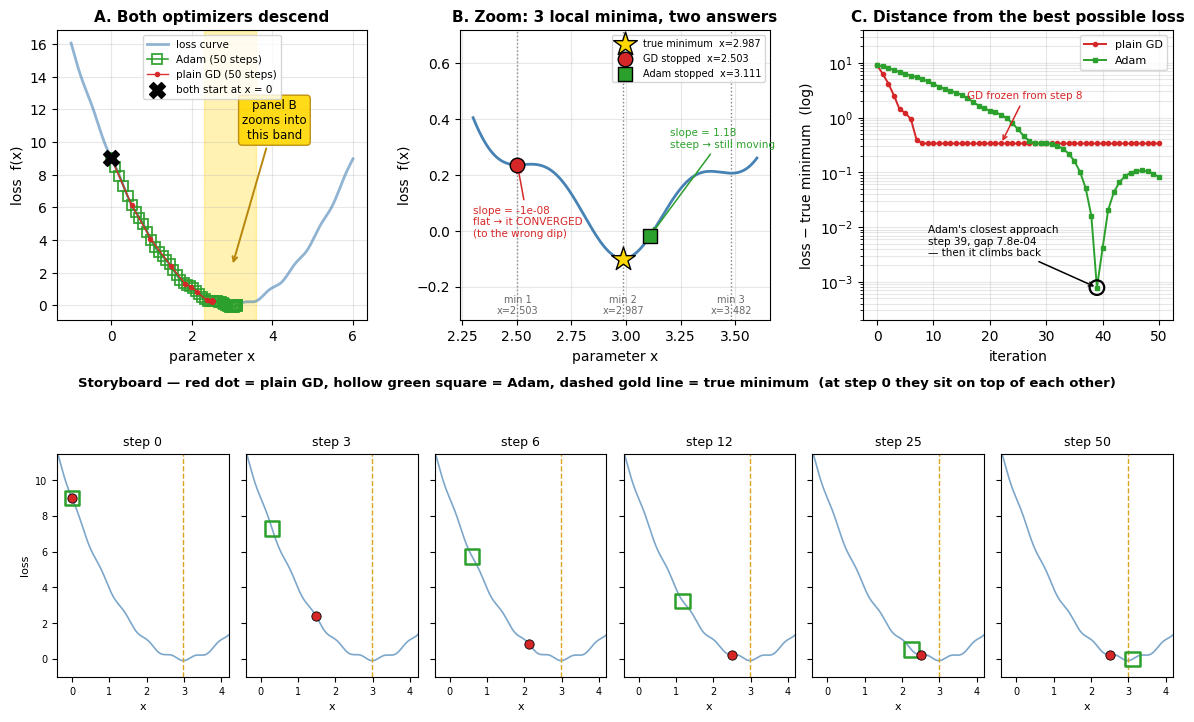

📊 Visual Analysis:
True minimum on [-1, 6]: x = 2.9871, loss = -0.0998  (brute-force grid)
Local minima inside the panel-B zoom (2.3, 3.6): x=2.5028 (f=0.2368), x=2.9871 (f=-0.0998), x=3.4824 (f=0.2064)
Simple GD: Final x = 2.5028, Loss = 0.2368, slope = -9.81e-09
Adam:      Final x = 3.1110, Loss = -0.0178, slope = 1.18e+00

Step table (the six storyboard frames):
 step |     GD x   GD loss |   Adam x  Adam loss
----------------------------------------------------
    0 |   0.0000    9.0000 |   0.0000     9.0000
    3 |   1.4731    2.4144 |   0.3004     7.3013
    6 |   2.1259    0.8308 |   0.6011     5.7280
   12 |   2.4992    0.2368 |   1.1781     3.2485
   25 |   2.5027    0.2368 |   2.2516     0.5100
   50 |   2.5028    0.2368 |   3.1110    -0.0178

What the figure actually shows (not what the textbook slogan says):
• Plain GD dropped fastest — by step 12 it was at x = 2.4992 and it
  never moved again. Its slope there is -9.8e-09: it CONVERGED —
  to a dimple that is not the lowe

In [3]:
# Interactive Example: Comparing Optimizers
# VISUAL: two optimizers on the SAME bumpy loss curve — where each one stops, and when.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# WHAT: a parabola with a ripple stirred into it. WHY: the parabola alone has one
# minimum and every optimizer finds it, which teaches nothing. The 0.1*sin(10x) term
# adds shallow dimples, so an optimizer can converge perfectly to the WRONG place.
def loss_function(x):
    return (x - 3)**2 + 0.1 * np.sin(10*x)  # Noisy loss landscape

def loss_gradient(x):
    return 2 * (x - 3) + 0.1 * 10 * np.cos(10*x)

# The honest reference point: the lowest value on the interval, found by brute force
# on a fine grid. Neither optimizer is told about it — it is only used to score them.
x_grid = np.linspace(-1, 6, 700_001)
f_grid = loss_function(x_grid)
x_star = float(x_grid[f_grid.argmin()])
f_star = float(f_grid.min())

# Track paths for visualization
simple_path = [0.0]
adam_path = [0.0]
simple_loss = [loss_function(0.0)]
adam_loss = [loss_function(0.0)]

# Simple GD
x_simple = 0.0
for i in range(50):
    x_simple = x_simple - 0.1 * loss_gradient(x_simple)
    simple_path.append(x_simple)
    simple_loss.append(loss_function(x_simple))

# Adam optimizer
adam = AdamOptimizer(lr=0.1)
x_adam = 0.0
for i in range(50):
    grad = loss_gradient(x_adam)
    x_adam = adam.update(x_adam, grad)
    adam_path.append(x_adam)
    adam_loss.append(loss_function(x_adam))

simple_path, adam_path = np.array(simple_path), np.array(adam_path)
simple_loss, adam_loss = np.array(simple_loss), np.array(adam_loss)

# WHAT: every local minimum inside the zoom window, found the same brute-force way.
# WHY: the caption claims the ripple "adds extra minima" — this counts them so the
# claim is checkable instead of asserted, and marks each one on the picture.
ZOOM = (2.30, 3.60)   # the window where the ripple decides the outcome
xz_fine = np.linspace(*ZOOM, 200_001)
fz_fine = loss_function(xz_fine)
dips = [(float(xz_fine[i]), float(fz_fine[i])) for i in range(1, len(xz_fine) - 1)
        if fz_fine[i] < fz_fine[i - 1] and fz_fine[i] < fz_fine[i + 1]]

# Where Adam came closest to the true minimum, and whether it stayed there.
adam_gap = adam_loss - f_star
k_closest = int(adam_gap.argmin())

# ---------------------------------------------------------------- the figure ----
# Two nested grids: the top row needs three roomy panels, the bottom row needs six
# thumbnails packed tightly. One GridSpec cannot give both spacings.
fig = plt.figure(figsize=(14.4, 8.4))
outer = gridspec.GridSpec(2, 1, height_ratios=[1.3, 1.0], hspace=0.52, figure=fig)
top = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[0], wspace=0.30)
bot = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=outer[1], wspace=0.10)

# --- A: the whole landscape, with both walks drawn on it -------------------------
# Adam is drawn as HOLLOW squares underneath and GD as small filled dots on top:
# the two walks overlap almost exactly here, and filled-over-filled would hide one
# of them completely — the reader would see one trail and the caption would claim two.
axA = fig.add_subplot(top[0])
xs = np.linspace(-1, 6, 600)
axA.plot(xs, loss_function(xs), color="steelblue", lw=2, alpha=0.6, label="loss curve")
axA.plot(adam_path, adam_loss, "s-", color="tab:green", ms=7, lw=1.2, mfc="none",
         mew=1.3, alpha=0.95, label="Adam (50 steps)", zorder=3)
axA.plot(simple_path, simple_loss, "o-", color="tab:red", ms=3.0, lw=1.0,
         alpha=0.95, label="plain GD (50 steps)", zorder=4)
axA.scatter([0], [loss_function(0.0)], marker="X", s=130, color="black",
            zorder=6, label="both start at x = 0")
axA.axvspan(*ZOOM, color="gold", alpha=0.30)
axA.annotate("panel B\nzooms into\nthis band", xy=(3.0, 2.4), xytext=(4.05, 10.2),
             fontsize=8.5, color="black", ha="center",
             bbox=dict(boxstyle="round,pad=0.3", fc="gold", ec="darkgoldenrod", alpha=0.9),
             arrowprops=dict(arrowstyle="->", color="darkgoldenrod", lw=1.4))
axA.set_xlabel("parameter x")
axA.set_ylabel("loss  f(x)")
axA.set_title("A. Both optimizers descend", fontsize=11, fontweight="bold")
axA.legend(fontsize=7.5, loc="upper center")
axA.grid(alpha=0.3)

# --- B: the zoom that shows they did NOT stop in the same place ------------------
axB = fig.add_subplot(top[1])
xz = np.linspace(*ZOOM, 900)
axB.plot(xz, loss_function(xz), color="steelblue", lw=2, zorder=2)
# Mark every local minimum the ripple created, so "extra minima" is visible, not asserted.
for j, (dx, dy) in enumerate(dips):
    axB.axvline(dx, color="grey", ls=":", lw=1, zorder=1)
    # Labels sit along the FLOOR of the panel: the top-right corner belongs to the
    # legend, and a label parked under a legend box is a label nobody can read.
    axB.text(dx, -0.305, f"min {j+1}\nx={dx:.3f}", fontsize=7, ha="center",
             va="bottom", color="dimgrey")
axB.scatter([x_star], [f_star], marker="*", s=320, color="gold", edgecolor="black",
            zorder=6, label=f"true minimum  x={x_star:.3f}")
axB.scatter([simple_path[-1]], [simple_loss[-1]], s=110, color="tab:red",
            edgecolor="black", zorder=6, label=f"GD stopped  x={simple_path[-1]:.3f}")
axB.scatter([adam_path[-1]], [adam_loss[-1]], marker="s", s=110, color="tab:green",
            edgecolor="black", zorder=6, label=f"Adam stopped  x={adam_path[-1]:.3f}")
# Both call-outs live INSIDE the axes: text that spills past the frame lands on the
# neighbouring panel's title and the reader cannot tell which plot it belongs to.
axB.set_xlim(2.24, 3.66)
axB.set_ylim(-0.32, 0.72)
axB.annotate(f"slope = {loss_gradient(simple_path[-1]):.0e}\nflat → it CONVERGED\n(to the wrong dip)",
             xy=(simple_path[-1], simple_loss[-1]), xytext=(2.30, -0.02),
             fontsize=7.5, color="tab:red", ha="left",
             arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.1))
axB.annotate(f"slope = {loss_gradient(adam_path[-1]):.2f}\nsteep → still moving",
             xy=(adam_path[-1], adam_loss[-1]), xytext=(3.20, 0.30),
             fontsize=7.5, color="tab:green", ha="left",
             arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.1))
axB.set_xlabel("parameter x")
axB.set_ylabel("loss  f(x)")
axB.set_title(f"B. Zoom: {len(dips)} local minima, two answers", fontsize=11, fontweight="bold")
axB.legend(fontsize=7, loc="upper right")
axB.grid(alpha=0.3)

# --- C: how far above the true minimum each one still is, step by step ------------
# Log scale on (loss - true minimum): plotting raw loss hides the whole story in the
# bottom 4% of the axis, because both runs fall from 9.0 to under 0.4.
axC = fig.add_subplot(top[2])
axC.plot(simple_loss - f_star, "o-", color="tab:red", ms=3, lw=1.4, label="plain GD")
axC.plot(adam_gap, "s-", color="tab:green", ms=3, lw=1.4, label="Adam")
axC.scatter([k_closest], [adam_gap[k_closest]], s=110, facecolor="none",
            edgecolor="black", lw=1.6, zorder=6)
axC.annotate(f"Adam's closest approach\nstep {k_closest}, gap {adam_gap[k_closest]:.1e}\n"
             f"— then it climbs back",
             xy=(k_closest, adam_gap[k_closest]), xytext=(9, 3e-3),
             fontsize=7.5, ha="left",
             arrowprops=dict(arrowstyle="->", color="black", lw=1.1))
axC.annotate("GD frozen from step 8", xy=(22, simple_loss[22] - f_star),
             xytext=(16, 2.2), fontsize=7.5, color="tab:red",
             arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.1))
axC.set_yscale("log")
axC.set_ylim(2e-4, 40)
axC.set_xlabel("iteration")
axC.set_ylabel("loss − true minimum  (log)")
axC.set_title("C. Distance from the best possible loss", fontsize=11, fontweight="bold")
axC.legend(fontsize=8, loc="upper right")
axC.grid(alpha=0.3, which="both")

# --- bottom row: the same two walks replayed as a storyboard ---------------------
SNAPS = [0, 3, 6, 12, 25, 50]
xs_f = np.linspace(-0.4, 4.2, 320)
for col, k in enumerate(SNAPS):
    ax = fig.add_subplot(bot[col])
    ax.plot(xs_f, loss_function(xs_f), color="steelblue", lw=1.2, alpha=0.7)
    ax.axvline(x_star, color="goldenrod", ls="--", lw=1)
    # Same trick as panel A: hollow green square so an overlapping red dot still shows.
    ax.scatter([adam_path[k]], [adam_loss[k]], marker="s", s=110, facecolor="none",
               edgecolor="tab:green", lw=1.8, zorder=5)
    ax.scatter([simple_path[k]], [simple_loss[k]], s=45, color="tab:red",
               edgecolor="black", lw=0.6, zorder=6)
    ax.set_ylim(-1.0, 11.5)
    ax.set_xlim(-0.4, 4.2)
    ax.set_title(f"step {k}", fontsize=9)
    ax.set_xlabel("x", fontsize=8)
    ax.tick_params(labelsize=7)
    if col == 0:
        ax.set_ylabel("loss", fontsize=8)
    else:
        ax.set_yticklabels([])
fig.text(0.5, 0.455, "Storyboard — red dot = plain GD, hollow green square = Adam, "
                     "dashed gold line = true minimum  (at step 0 they sit on top of each other)",
         ha="center", fontsize=9.5, fontweight="bold")
plt.show()

# --- the numbers behind the picture ---------------------------------------------
print("📊 Visual Analysis:")
print("=" * 68)
print(f"True minimum on [-1, 6]: x = {x_star:.4f}, loss = {f_star:.4f}  (brute-force grid)")
print(f"Local minima inside the panel-B zoom {ZOOM}: "
      + ", ".join(f"x={d:.4f} (f={v:.4f})" for d, v in dips))
print(f"Simple GD: Final x = {simple_path[-1]:.4f}, Loss = {simple_loss[-1]:.4f}, "
      f"slope = {loss_gradient(simple_path[-1]):.2e}")
print(f"Adam:      Final x = {adam_path[-1]:.4f}, Loss = {adam_loss[-1]:.4f}, "
      f"slope = {loss_gradient(adam_path[-1]):.2e}")

print("\nStep table (the six storyboard frames):")
print(f"{'step':>5} | {'GD x':>8} {'GD loss':>9} | {'Adam x':>8} {'Adam loss':>10}")
print("-" * 52)
for k in SNAPS:
    print(f"{k:>5} | {simple_path[k]:>8.4f} {simple_loss[k]:>9.4f} | "
          f"{adam_path[k]:>8.4f} {adam_loss[k]:>10.4f}")

print("\nWhat the figure actually shows (not what the textbook slogan says):")
print(f"• Plain GD dropped fastest — by step 12 it was at x = {simple_path[12]:.4f} and it")
print(f"  never moved again. Its slope there is {loss_gradient(simple_path[-1]):.1e}: it CONVERGED —")
print("  to a dimple that is not the lowest point.")
print(f"• Adam was SLOWER here: at step 12 it was still at x = {adam_path[12]:.4f}, loss "
      f"{adam_loss[12]:.4f}.")
print(f"• Adam's best moment was step {k_closest} (x = {adam_path[k_closest]:.4f}, only "
      f"{adam_gap[k_closest]:.1e} above the true minimum) —")
print(f"  and it did not stay: by step 50 it had overshot to x = {adam_path[-1]:.4f}, "
      f"{adam_gap[-1]:.4f} above the minimum again.")
print(f"• Adam still ended lower than GD ({adam_loss[-1]:.4f} vs {simple_loss[-1]:.4f}), but "
      "because it walked past the dimple,")
print(f"  not because it converged: its slope at the stopping point is "
      f"{loss_gradient(adam_path[-1]):.2f}, far from zero.")
print(f"• Neither reached the true minimum: GD is {simple_loss[-1] - f_star:.4f} above it, "
      f"Adam {adam_gap[-1]:.4f}.")
print("\n💡 'Lower loss' and 'converged' are two different claims. Read both before you ship.")

### 📊 What to see in the figure above

**Panel A — the honest overview.** Both optimizers start at the black ✕ at `x = 0`, on a
loss of 9.0, and both walk down the blue curve to the right. Adam is drawn as **hollow
green squares** and plain gradient descent as **small red dots inside them** — for most of
the descent the two walks lie almost on top of each other, which is the point: at this
zoom they look like the same success story. That is exactly why the gold band exists —
panel B magnifies it.

**Panel B — they did not stop in the same place, and they failed differently.** Inside the
gold window the curve is not a single valley. The `0.1·sin(10x)` ripple carves **three**
local minima, and each one is marked with a dotted grey line and labelled `min 1/2/3` with
its x-position: `x ≈ 2.503`, `x ≈ 2.987` and `x ≈ 3.482`. Two of them are obvious valleys;
the third, at `x ≈ 3.482`, is a barely-visible kink only 0.006 deep — and that is itself
the lesson, because a dip too shallow to see on a plot is still deep enough to trap a
gradient. The red dot (plain gradient descent) sits in the left-hand dimple at `x ≈ 2.503`;
the slope printed beside it is ~1e-08, i.e. flat. Gradient descent *did* converge — to the
wrong dimple. The green square (Adam) sits at `x ≈ 3.111`, past the gold star, and the
slope beside it is **1.18** — nowhere near zero. Adam has not converged at all; it is still
moving when the loop runs out of iterations. The gold star, `x ≈ 2.987`, is the true
minimum, and **neither marker is on it**.

**Panel C — who was actually faster, and what "faster" hides.** This is the distance still
to go, on a log axis. The red curve falls fastest and then goes **perfectly flat from about
step 8** — that flat line is the wrong dimple, seen from above; the red arrow points at it.
The green curve descends more slowly and crosses below red at **step 31**. Then watch the
circled point: at **step 39 Adam is only 7.8e-04 above the true minimum** — essentially on
it — and it does **not stay there**. The green curve turns and climbs back up by two orders
of magnitude, ending at **0.082** above the minimum. That V-shape is Adam's momentum
carrying it straight through the valley and out the other side. So the common slogan "Adam
converges faster" is **false twice** on this problem: it was slower for the first 30 steps,
and what looks like convergence at step 39 is a fly-past.

**Storyboard — the race, six frames.** Watch the two markers, not the curve. At **step 0**
they sit on the same point, so you see the red dot inside the green square. By frame 3 red
has already moved further than green will move by frame 12. From frame 12 onward the red
dot is frozen at the same spot in every remaining frame while the green square keeps
crawling right, passes the dashed gold line between frames 25 and 50, and ends past it.
The step table underneath prints the same six positions, so you can check the frames
against the numbers.

### Best Practices

**Best Practices for Optimization and Statistics in ML:**

- **Optimizer Selection**: Use Adam for most cases, SGD with momentum for large datasets
- **Learning Rate Scheduling**: Reduce learning rate during training for better convergence
- **Regularization**: Start with L2, use L1 for feature selection
- **Cross-Validation**: Always use k-fold cross-validation for reliable evaluation
- **Statistical Testing**: Use appropriate tests (t-test, chi-square) for model comparison

---

# Part 3: AFTER

## Analyzing Results and Understanding Implications

### What Happens Next?

After understanding optimization and statistics:

- **Better Training**: You can choose appropriate optimizers for your ML problems
- **Model Evaluation**: You understand statistical measures for model assessment
- **Overfitting Control**: You can apply regularization techniques effectively
- **Next Module**: Dimensionality reduction builds on these optimization concepts

### How This Connects to Machine Learning

- **Training Efficiency**: Right optimizer can speed up training significantly
- **Model Selection**: Statistical tests help choose between models
- **Generalization**: Understanding bias-variance helps build better models
- **Production**: Statistical measures guide deployment decisions


> 💡 **Key Insight**: Optimization and statistics work together in ML. Optimizers train models efficiently, while statistics help you evaluate whether your trained models are actually good. Both are essential for successful ML projects.


In [4]:
# Example: Understanding Results and Implications

import numpy as np

# Example: Analyzing model performance with statistics
def analyze_model_performance(train_scores, val_scores):
    """Analyze model performance using statistical measures"""
    train_mean = np.mean(train_scores)
    val_mean = np.mean(val_scores)
    train_std = np.std(train_scores)
    val_std = np.std(val_scores)
    
    gap = train_mean - val_mean
    
    print("Model Performance Analysis:")
    print(f"Training: {train_mean:.4f} ± {train_std:.4f}")
    print(f"Validation: {val_mean:.4f} ± {val_std:.4f}")
    print(f"Gap: {gap:.4f}")
    
    if gap > 0.1:
        print("\n⚠️  Large gap suggests overfitting!")
        print("Consider: regularization, more data, simpler model")
    elif gap < 0.01:
        print("\n✓ Good generalization!")
    
    return {
        'train_mean': train_mean, 'val_mean': val_mean,
        'gap': gap
    }

# Example
train_scores = [0.95, 0.94, 0.96, 0.95, 0.94]
val_scores = [0.82, 0.81, 0.83, 0.82, 0.81]
analyze_model_performance(train_scores, val_scores)

# Additional visualizations can show optimizer convergence paths and loss landscapes
# Regularization examples: L1 (Lasso) encourages sparsity, L2 (Ridge) prevents large weights
# In real ML training, optimizers like Adam are used in frameworks like scikit-learn, PyTorch, TensorFlow

Model Performance Analysis:
Training: 0.9480 ± 0.0075
Validation: 0.8180 ± 0.0075
Gap: 0.1300

⚠️  Large gap suggests overfitting!
Consider: regularization, more data, simpler model


{'train_mean': np.float64(0.9480000000000001),
 'val_mean': np.float64(0.818),
 'gap': np.float64(0.13000000000000012)}

---

## ⚠️ Where this breaks

- **Neither optimizer in this notebook found the minimum.** Take the printed results seriously. On
  `f(x) = (x−3)² + 0.1·sin(10x)`, plain gradient descent stopped at **x = 2.5028** with loss 0.2368, and
  Adam stopped at **x = 3.1110** with loss −0.0178. The true minimum on that interval is at
  **x ≈ 2.9871, where f ≈ −0.0998**. Check it yourself in one line:
  `xs = np.linspace(-1, 6, 700001); xs[((xs-3)**2 + 0.1*np.sin(10*xs)).argmin()]`.
  Worse, the two failures are different in kind: gradient descent genuinely converged — to the *wrong*
  local minimum (its derivative there is ≈ −1e-08, i.e. flat). Adam's derivative at its stopping point is about
  **1.18**, nowhere near zero: it has not converged at all, it has simply wandered somewhere lower. "Adam
  won" and "Adam converged" are not the same claim.
- **Adam's advantage is problem-specific.** Wilson, Roelofs, Stern, Srebro and Recht argued the opposite
  case in *"The Marginal Value of Adaptive Gradient Methods in Machine Learning"* (NeurIPS 2017): on
  several standard tasks, plain SGD with momentum reached *better test performance* than adaptive methods
  that had lower training loss. The condition that must hold before "Adam is better" is that you measured
  it, on your problem, on held-out data.
- **The overfitting diagnostic here is arithmetic, not statistics.** The `analyze_model_performance` cell
  compares two means with hand-supplied numbers and calls a 0.13 gap "overfitting". Whether a gap that
  size is real depends on how many folds produced it and how much they varied — Unit 5, notebook 02 shows
  the honest version with confidence intervals, and notes that cross-validation folds share data, so the
  usual test is optimistic.


---

## 💬 Discuss

1. Gradient descent converged to a local minimum; Adam did not converge but ended up lower. If you had to
   ship one of them, which would you choose, and what would you write in the report about the one you
   rejected?
2. Adam had a published convergence flaw for three years and a regularization bug for four, while being
   the field's default. What does that say about how you should treat "everyone uses it" as evidence?
   Name one thing in your own toolkit you have never questioned.
3. This module's framing is "choose an optimizer, then evaluate with statistics." Argue the reverse order:
   what would you have to decide about evaluation *before* you were allowed to compare two optimizers at
   all?


### Common Pitfalls and How to Avoid Them

**Common Pitfalls and How to Avoid Them:**

1. **Overfitting**: Model performs well on training but poorly on validation
   - Solution: Use regularization, cross-validation, more data, simpler models

2. **Wrong Optimizer**: Using inappropriate optimizer for the problem
   - Solution: Understand problem characteristics, try different optimizers

3. **Ignoring Statistics**: Not using statistical measures for evaluation
   - Solution: Always use proper statistical tests and confidence intervals

### Advanced Topics

**Advanced Topics for Further Learning:**

- **Second-Order Methods**: Newton's method, quasi-Newton methods (BFGS, L-BFGS)
- **Bayesian Optimization**: For hyperparameter tuning
- **Ensemble Methods**: Combining multiple models statistically
- **Statistical Learning Theory**: Theoretical foundations of ML

---

# Summary

## Key Takeaways

## Key Takeaways

In this module, you've learned how to effectively train and evaluate machine learning models:

1. **Optimization Algorithms**: You discovered that basic gradient descent has limitations (slow convergence, getting stuck in local minima). Advanced optimizers like Adam, RMSprop, and SGD with momentum adapt learning rates per parameter and use momentum to smooth updates. Adam combines the best of both worlds and is the default choice for most ML problems.

2. **Statistical Foundations**: You learned essential statistical measures for ML: mean, variance, standard deviation, and distributions. These help you understand data characteristics, evaluate model performance, and make informed decisions about model improvements. Statistics provide the language for discussing model quality.

3. **Regularization**: You understood that overfitting occurs when models memorize training data instead of learning patterns. L1 regularization (Lasso) adds absolute value of weights to loss, encouraging sparsity. L2 regularization (Ridge) adds squared weights, preventing extreme values. Both help models generalize better to new data.

4. **Bias-Variance Tradeoff**: You learned the fundamental tension in ML: simple models have high bias (underfitting) but low variance, while complex models have low bias but high variance (overfitting). The goal is finding the sweet spot - a model complex enough to capture patterns but simple enough to generalize. This guides your model selection decisions.

## 🔗 How This Connects to Other Modules

**What you learned here connects to:**

- **Module 01**: Matrix operations make optimizers efficient
- **Module 02**: You USE the gradients from Module 02 in optimizers (Adam, SGD)
- **Module 04**: Optimization helps find optimal reduced dimensions in PCA
- **Module 05**: Statistical foundations from here extend to probabilistic inference

> 💡 **The Flow**: 
> - Module 01: Data as matrices
> - Module 02: Compute gradients (vectors)
> - Module 03: Use gradients for optimization ← **You are here!**
> - Module 04: Apply optimization + linear algebra for dimensionality reduction
> - Module 05: Use statistics for evaluation and inference

## Next Steps

1. Complete the exercises in the `exercises/` folder
2. Review the solutions if needed
3. Move on to **Module 04: Dimensionality Reduction Techniques and Data Representation**
   - You'll combine eigenvalues (Module 01) + optimization (this module) for PCA
   - **Connection**: PCA = Eigenvalue decomposition (Module 01) + Optimization (Module 03)

---

**Ready for exercises?** Navigate to the `exercises/` folder and start practicing!

## 📚 References

1. Robbins, H., & Monro, S. (1951). *A Stochastic Approximation Method*. The Annals of Mathematical Statistics, 22(3), 400–407.
2. Bottou, L., Curtis, F. E., & Nocedal, J. (2018). *Optimization Methods for Large-Scale Machine Learning*. SIAM Review, 60(2), 223–311. <https://arxiv.org/abs/1606.04838>
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 8: Optimization for Training Deep Models. MIT Press. <https://www.deeplearningbook.org/>
4. Liu, J., Su, J., Yao, X., Jiang, Z., Lai, G., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982> — matrix-aware optimization: the direction large-scale training took in 2025.
5. Wen, K., Hall, D., Ma, T., & Liang, P. (2025). *Fantastic Pretraining Optimizers and Where to Find Them*. arXiv. <https://arxiv.org/abs/2509.02046> — a fair, tuned comparison of ten optimizers — the protocol this module's experiments imitate.
